In [4]:
import numpy as np 
import matplotlib.pyplot as plt

In [56]:
N=10000

ms=np.random.uniform(10, 100, size=(N, 2))
print(ms.shape)
m1, m2= ms[:, 0], ms[:, 1] 
costhetas=np.random.uniform(-1, 1, size=(N, 2))
theta1=np.arccos(costhetas[:,0])
theta2=np.arccos(costhetas[:,1])
chis=np.random.uniform(0, 1, size=(N, 2))
chi1, chi2= chis[:, 0], chis[:, 1] 
print(m1.shape, m2.shape, theta1.shape, theta2.shape, chi1.shape, chi2.shape)
BBH={"m1": m1, "m2": m2, "theta1": theta1, "theta2": theta2, "chi1": chi1, "chi2": chi2, "ctheta1": costhetas[:, 0], "ctheta2": costhetas[:, 1] } 

(10000, 2)
(10000,) (10000,) (10000,) (10000,) (10000,) (10000,)


In [57]:
BBH["Mtot"] =  BBH["m1"]+BBH["m2"]
BBH["chieff"] = (BBH["chi1"]*BBH["m1"]*BBH["ctheta1"]+BBH["chi2"]*BBH["m2"]*BBH["ctheta2"]) / BBH["Mtot"]
BBH["smr"]=(BBH["m1"]*BBH["m2"])/(BBH["Mtot"]*BBH["Mtot"]) * 0.25
BBH["chirpM"]=((BBH["m1"]*BBH["m2"])**3 / BBH["Mtot"])**(1./5) 

nu=4.916 * 10**(-5)
BBH["r0"]=(BBH["Mtot"]/ (np.pi*np.pi * nu*nu))**(1./3) 

BBH["t0"]= nu *50/256 * (BBH["r0"]**4)/(BBH["m1"]*BBH["m2"]*BBH["Mtot"]) 

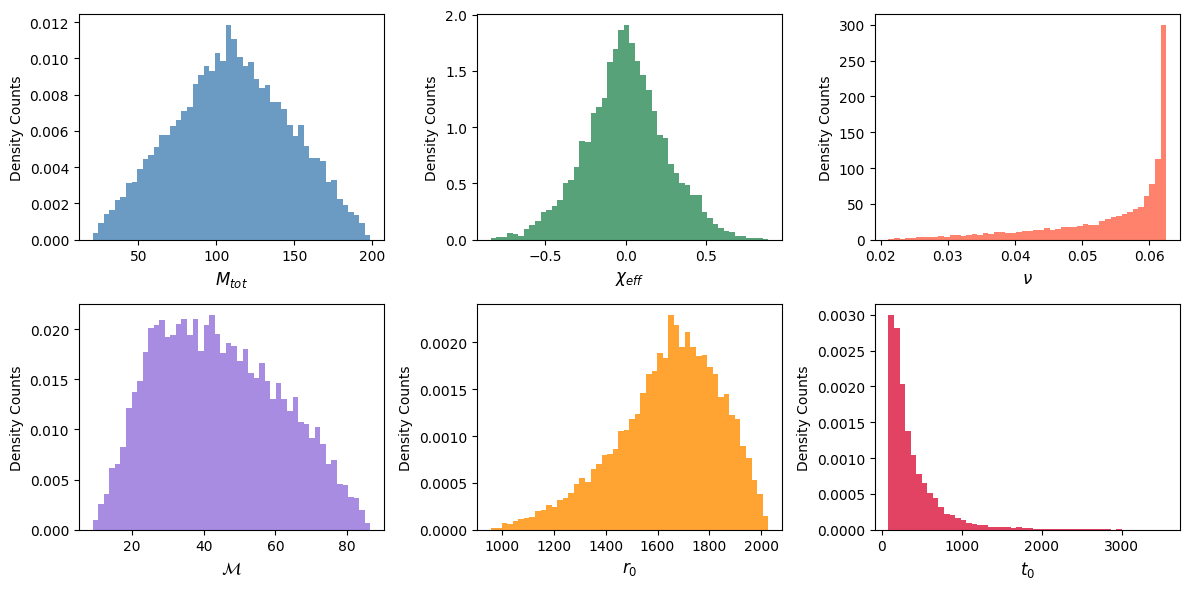

In [58]:
fig, axes = plt.subplots(2, 3, figsize=(12, 6))

quantities = {
    "Mtot":   (r'$M_{tot}$',    'steelblue'),
    "chieff": (r'$\chi_{eff}$', 'seagreen'),
    "smr":    (r'$\nu$',        'tomato'),
    "chirpM": (r'$\mathcal{M}$','mediumpurple'),
    "r0":     (r'$r_0$',        'darkorange'),
    "t0":     (r'$t_0$',        'crimson'),
}

for ax, (key, (label, color)) in zip(axes.flat, quantities.items()):
    BBH[key+"_hist"]= ax.hist(BBH[key], bins=50, color=color, alpha=0.8, edgecolor='none', density=True)
    ax.set_xlabel(label, fontsize=12)
    ax.set_ylabel('Density Counts')

plt.tight_layout()
# plt.savefig("histograms.png", dpi=150)
plt.show()

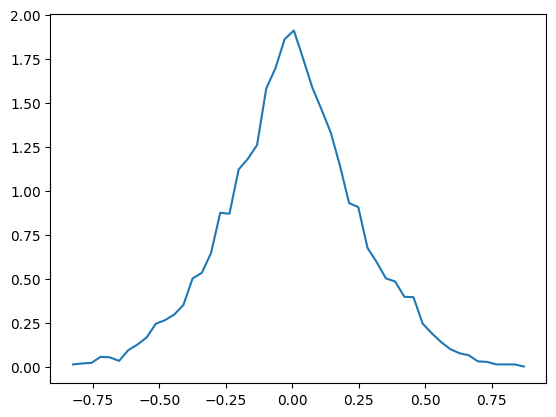

In [59]:
counts, edges = BBH["chieff_hist"][0:2]
centers = (edges[:-1] + edges[1:]) / 2

plt.plot(centers, counts)

gamma: 0.17+-0.01; x: -0.001+-0.007


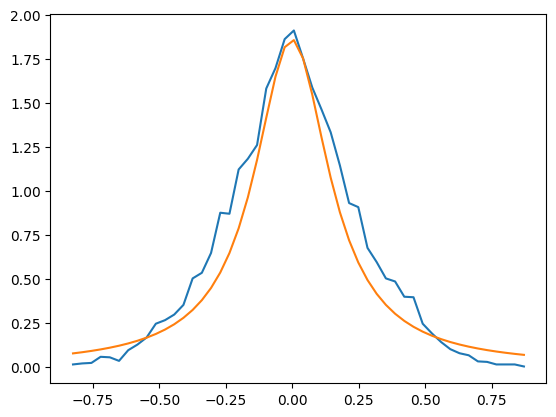

In [62]:
from scipy.optimize import curve_fit
def curve(x, gamma, x0):
    return (1/np.pi * gamma/ ((x-x0)**2 + gamma**2))

xfit=centers
yfit=counts

popt, pcov=curve_fit(curve, xfit, yfit, p0=(0.17, 0.000))
gamma, x0 = popt[:]
sgamma, sx0 = np.sqrt(np.diag(pcov))
print(rf"gamma: {gamma:.2f}+-{sgamma:.2f}; x: {x0:.3f}+-{sx0:.3f}")


plt.plot(centers, counts)
plt.plot(xfit, curve(xfit, gamma, x0))